# Imports

In [25]:
import numpy as np
import math
import time

from scipy import stats
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
n_values = range(2, 1000)

n_intentos = 5

In [3]:
matrices = []

for n in n_values:
    matrices.append(np.random.randint(1,10, size=(n, n)))

# Algoritmos

In [4]:
import time
import numpy as np

times_two_if = []
times_one_if = []
times_one_if_comprehension = []
times_numpy = []

sum_two_if = []
sum_one_if = []
sum_one_if_comprehension = []
sum_numpy = []

for n in n_values:
    matriz = matrices[n-2]

    # Inicio Algoritmo
    time_intentos = []
    sum_intentos = []

    for intento in range(n_intentos):
        inicio_two_if = time.perf_counter()

        suma = 0
        for i in range(n):
            for j in range(n):
                if i == j:
                    suma += matriz[i][j]

        fin_two_if = time.perf_counter()

        sum_intentos.append(suma)
        time_intentos.append(fin_two_if - inicio_two_if)

    times_two_if.append(np.mean(time_intentos))
    sum_two_if.append(np.mean(sum_intentos))

    # Inicio Algoritmo
    time_intentos = []
    sum_intentos = []

    for intento in range(n_intentos):
        inicio_one_if = time.perf_counter()

        suma = 0
        for i in range(n):
            suma += matriz[i][i]

        fin_one_if = time.perf_counter()

        sum_intentos.append(suma)
        time_intentos.append(fin_one_if - inicio_one_if)

    times_one_if.append(np.mean(time_intentos))
    sum_one_if.append(np.mean(sum_intentos))

    # Inicio Algoritmo
    time_intentos = []
    sum_intentos = []

    for intento in range(n_intentos):
        inicio_one_if_comprehension = time.perf_counter()

        suma = sum([matriz[i][i] for i in range(n)])

        fin_one_if_comprehension = time.perf_counter()

        sum_intentos.append(suma)
        time_intentos.append(fin_one_if_comprehension - inicio_one_if_comprehension)

    times_one_if_comprehension.append(np.mean(time_intentos))
    sum_one_if_comprehension.append(np.mean(sum_intentos))

    # Inicio Algoritmo
    time_intentos = []
    sum_intentos = []

    matriz_np = np.array(matriz)

    for intento in range(n_intentos):
        inicio_numpy = time.perf_counter()

        suma = np.trace(matriz_np)

        fin_numpy = time.perf_counter()

        sum_intentos.append(suma)
        time_intentos.append(fin_numpy - inicio_numpy)

    times_numpy.append(np.mean(time_intentos))
    sum_numpy.append(np.mean(sum_intentos))

# Validar Resultados

In [5]:
# Son los valores iguales
def validar_igualdad(*listas):
    if not listas:
        return True

    primera = listas[0]

    for i, lista in enumerate(listas[1:], start=2):
        if primera != lista:
            print(f"La lista 1 y la lista {i} son diferentes")
            return False

    return True

In [6]:
resultado = validar_igualdad(
    sum_two_if,
    sum_one_if,
    sum_one_if_comprehension,
    sum_numpy
)

print("¿Todas son iguales?: ", resultado)

¿Todas son iguales?:  True


# Complejidad computacional

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# AJUSTE DE COMPLEJIDAD EMPÍRICA
# ──────────────────────────────────────────────────────────────────────────────
# Si T(n) = C · nᵏ  →  log T = log C + k · log n
# Una regresión lineal sobre (log n, log T) devuelve la pendiente k,
# que es el exponente de complejidad (k≈1 → O(n), k≈2 → O(n²), etc.)
# ══════════════════════════════════════════════════════════════════════════════

In [32]:
def _r2(y, y_hat):
    ss_res = np.sum((y - y_hat)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    return 1 - ss_res/ss_tot if ss_tot > 0 else 0


def fit_complexity(n_vals, times):
    n = np.array(n_vals, dtype=float)
    t = np.array(times, dtype=float)

    log_n = np.log(n)
    log_t = np.log(t)

    models = []

    # ─────────────────────────────────────────────────────────────
    # O(1)
    # T(n) = c
    y_hat = np.full_like(t, np.mean(t))
    models.append(("O(1)", None, None, _r2(t, y_hat), y_hat))

    # ─────────────────────────────────────────────────────────────
    # O(log n)
    # T(n) = a + b log(n)
    slope, intercept, r, _, se = stats.linregress(log_n, t)
    y_hat = intercept + slope * log_n
    models.append(("O(log n)", slope, se, _r2(t, y_hat), y_hat))

    # ─────────────────────────────────────────────────────────────
    # O(n)
    # T(n) = a + b n
    slope, intercept, r, _, se = stats.linregress(n, t)
    y_hat = intercept + slope * n
    models.append(("O(n)", slope, se, _r2(t, y_hat), y_hat))

    # ─────────────────────────────────────────────────────────────
    # O(n log n)
    # T(n) = a + b n log(n)
    X = n * log_n
    slope, intercept, r, _, se = stats.linregress(X, t)
    y_hat = intercept + slope * X
    models.append(("O(n log n)", slope, se, _r2(t, y_hat), y_hat))

    # ─────────────────────────────────────────────────────────────
    # O(n^2)
    # T(n) = a + b n^2
    X = n**2
    slope, intercept, r, _, se = stats.linregress(X, t)
    y_hat = intercept + slope * X
    models.append(("O(n²)", slope, se, _r2(t, y_hat), y_hat))

    # ─────────────────────────────────────────────────────────────
    # O(n^k) (polinomial general)
    # T(n) = C n^k
    # log T(n) = log C + k log n
    k, logC, r, _, se = stats.linregress(log_n, log_t)
    y_hat = np.exp(logC) * n**k
    models.append((f"O(n^{int(math.ceil(k)):.0f})", k, se, r**2, y_hat))

    # ─────────────────────────────────────────────────────────────
    # O(a^n) (exponencial)
    # T(n) = C a^n
    # log T(n) = log C + n log a
    slope, intercept, r, _, se = stats.linregress(n, log_t)
    y_hat = np.exp(intercept + slope * n)
    models.append(("O(a^n)", slope, se, r**2, y_hat))

    # ─────────────────────────────────────────────────────────────
    # Seleccionar mejor modelo por R²
    best = max(models, key=lambda x: x[3])

    return dict(
        model=best[0],
        k=best[1],        # solo tiene sentido para polinomial
        se=best[2],
        R2=best[3],
        fitted=best[4],
        all_models=models
    )

In [ ]:
def label_k(k):
    for thresh, lbl in [(0.15,"O(1)"), (0.55,"O(log n)"),
                        (1.4,"O(n)"), (1.8,"O(n log n)"), (2.4,"O(n²)")]:
        if k < thresh: return lbl
    return f"O(n^{k:.2f})"

def fit_complexity_(n_vals, times):
    log_n = np.log(n_vals.astype(float))
    log_t = np.log(np.array(times, dtype=float))
    k, logC, r, _, se = stats.linregress(log_n, log_t)
    return dict(k=k, C=np.exp(logC), R2=r**2, se=se,
                fitted=np.exp(logC) * n_vals**k)

In [33]:
fit_two_if       = fit_complexity(np.array(n_values), times_two_if)
fit_one_if       = fit_complexity(np.array(n_values), times_one_if)
fit_comprehension= fit_complexity(np.array(n_values), times_one_if_comprehension)
fit_numpy        = fit_complexity(np.array(n_values), times_numpy)

In [36]:
# ── Tabla resumen ──────────────────────────────────────────────────────────────
print(f"{'Algoritmo':<24} {'k_emp':>7} {'±se':>7} {'Clase':>12} {'R²':>8}")
print("─" * 62)
for name, fit in [("two_if",       fit_two_if),
                  ("one_if",       fit_one_if),
                  ("comprehension",fit_comprehension),
                  ("numpy_trace",  fit_numpy)]:
    print(f"{name:<24} {fit['k']:7.3f} {fit['se']:7.3f} "
          f"{fit['model']:>12} {fit['R2']:8.4f}")

Algoritmo                  k_emp     ±se        Clase       R²
──────────────────────────────────────────────────────────────
two_if                     1.637   0.012       O(n^2)   0.9525
one_if                     0.731   0.013       O(n^1)   0.7634
comprehension              0.671   0.013       O(n^1)   0.7152
numpy_trace                0.001   0.000       O(a^n)   0.3690


# Visualizaciones individual

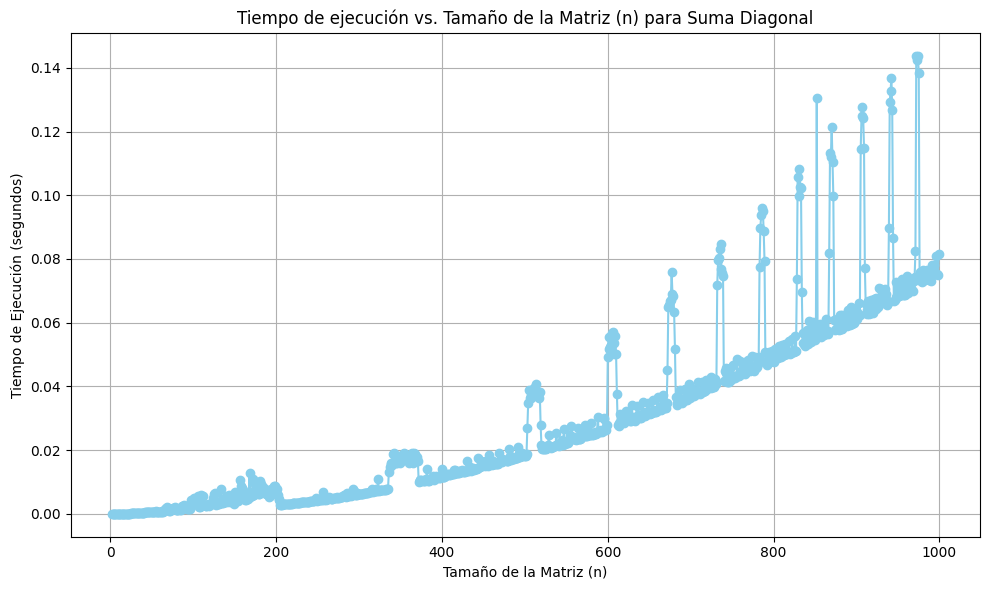

In [37]:
# Two if
plt.figure(figsize=(10, 6))
plt.plot(n_values, times_two_if, marker='o', linestyle='-', color='skyblue')
plt.title('Tiempo de ejecución vs. Tamaño de la Matriz (n) para Suma Diagonal')
plt.xlabel('Tamaño de la Matriz (n)')
plt.ylabel('Tiempo de Ejecución (segundos)')
plt.grid(True)
plt.tight_layout()
plt.show()

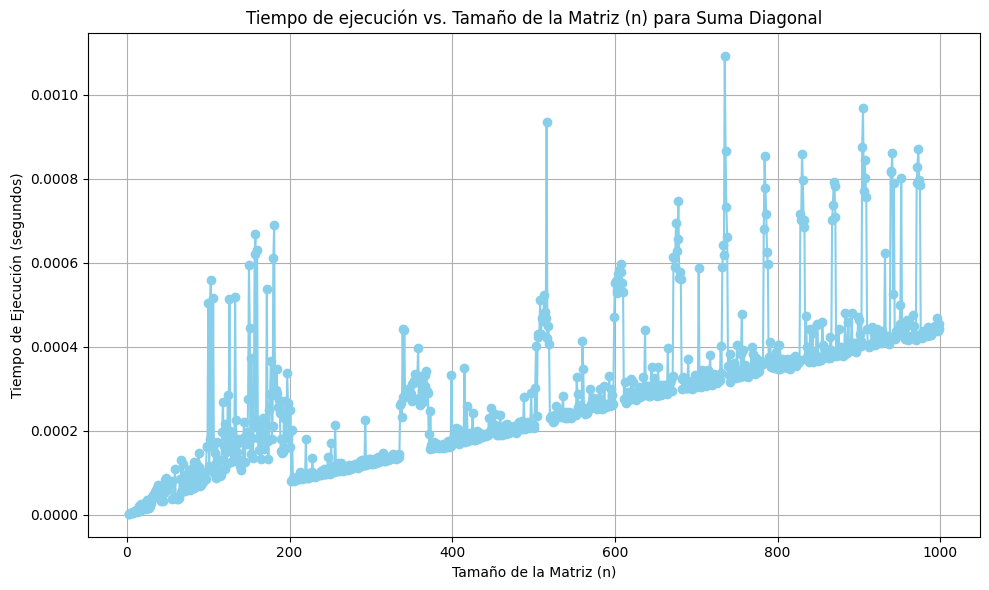

In [38]:
# One if
plt.figure(figsize=(10, 6))
plt.plot(n_values, times_one_if, marker='o', linestyle='-', color='skyblue')
plt.title('Tiempo de ejecución vs. Tamaño de la Matriz (n) para Suma Diagonal')
plt.xlabel('Tamaño de la Matriz (n)')
plt.ylabel('Tiempo de Ejecución (segundos)')
plt.grid(True)
plt.tight_layout()
plt.show()

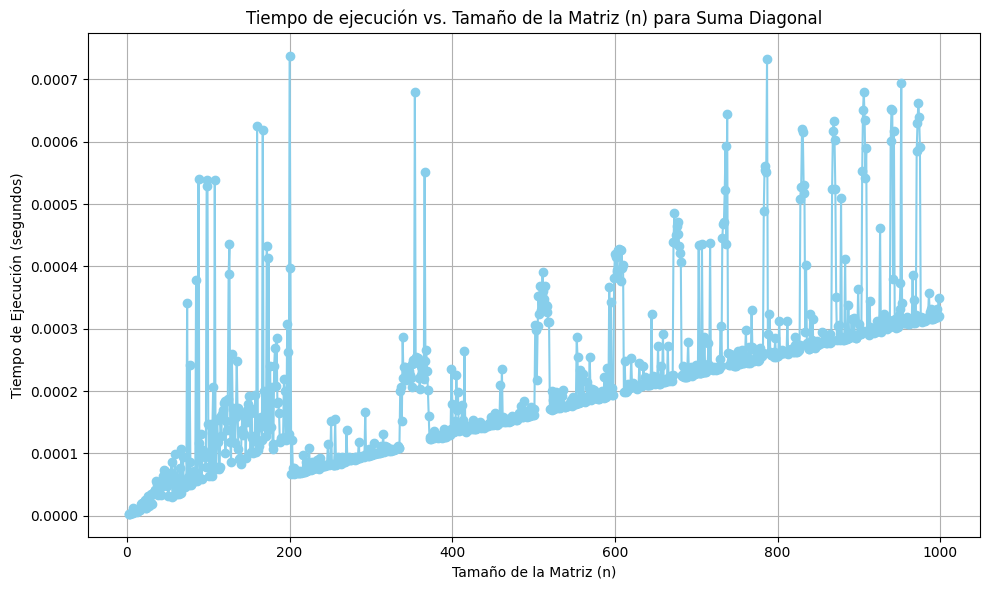

In [39]:
# One comprehension if
plt.figure(figsize=(10, 6))
plt.plot(n_values, times_one_if_comprehension, marker='o', linestyle='-', color='skyblue')
plt.title('Tiempo de ejecución vs. Tamaño de la Matriz (n) para Suma Diagonal')
plt.xlabel('Tamaño de la Matriz (n)')
plt.ylabel('Tiempo de Ejecución (segundos)')
plt.grid(True)
plt.tight_layout()
plt.show()

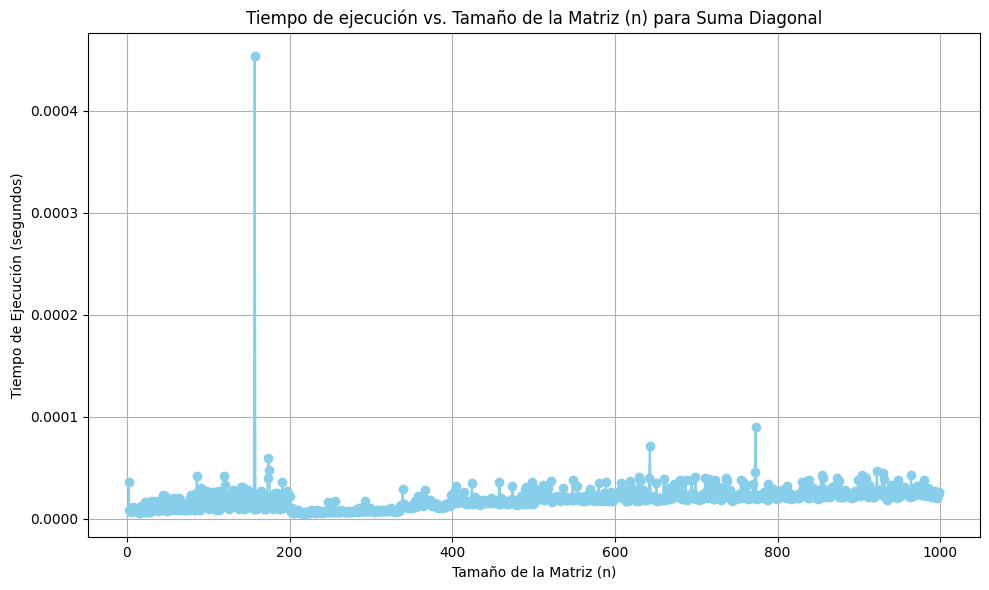

In [40]:
# One comprehension if
plt.figure(figsize=(10, 6))
plt.plot(n_values, times_numpy, marker='o', linestyle='-', color='skyblue')
plt.title('Tiempo de ejecución vs. Tamaño de la Matriz (n) para Suma Diagonal')
plt.xlabel('Tamaño de la Matriz (n)')
plt.ylabel('Tiempo de Ejecución (segundos)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Visualizacion conjunta

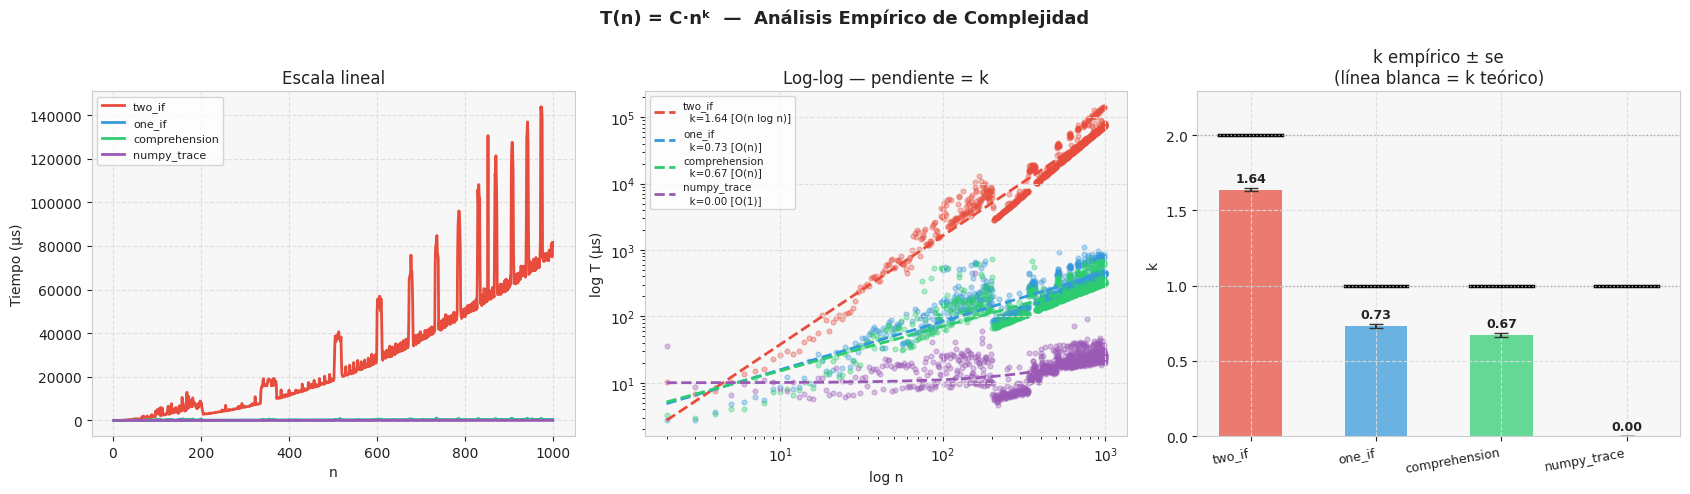

In [41]:
# ══════════════════════════════════════════════════════════════════════════════
# MATPLOTLIB  —  escala lineal + log-log + bar k
# ══════════════════════════════════════════════════════════════════════════════
ALGS = {
    "two_if":        dict(times=times_two_if,              fit=fit_two_if,        color="#E74C3C"),
    "one_if":        dict(times=times_one_if,              fit=fit_one_if,        color="#3498DB"),
    "comprehension": dict(times=times_one_if_comprehension,fit=fit_comprehension, color="#2ECC71"),
    "numpy_trace":   dict(times=times_numpy,               fit=fit_numpy,         color="#9B59B6"),
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.patch.set_facecolor("#ffffff")
for ax in axes:
    ax.set_facecolor("#f7f7f7")
    ax.tick_params(colors="#222222")
    ax.xaxis.label.set_color("#222222")
    ax.yaxis.label.set_color("#222222")
    ax.title.set_color("#222222")
    for sp in ax.spines.values(): sp.set_edgecolor("#cccccc")
    ax.grid(True, color="#dddddd", linestyle="--", alpha=0.9)

# ── Subplot 1: Escala lineal ───────────────────────────────────────────────────
for name, alg in ALGS.items():
    t_us = np.array(alg["times"]) * 1e6
    axes[0].plot(n_values, t_us, color=alg["color"], linewidth=2, label=name)
axes[0].set_xlabel("n"); axes[0].set_ylabel("Tiempo (μs)")
axes[0].set_title("Escala lineal")
axes[0].legend(facecolor="#ffffff", labelcolor="#222222", fontsize=8)

# ── Subplot 2: Escala log-log + recta OLS ─────────────────────────────────────
# La pendiente visible de cada recta punteada es k (el orden de complejidad)
for name, alg in ALGS.items():
    t_us = np.array(alg["times"]) * 1e6
    axes[1].scatter(n_values, t_us, color=alg["color"], s=12, alpha=0.35)
    k_str = f"k={alg['fit']['k']:.2f} [{label_k(alg['fit']['k'])}]"
    axes[1].plot(n_values, alg["fit"]["fitted"] * 1e6,
                 color=alg["color"], linewidth=2, linestyle="--",
                 label=f"{name}\n  {k_str}")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("log n"); axes[1].set_ylabel("log T (μs)")
axes[1].set_title("Log-log — pendiente = k")
axes[1].legend(facecolor="#ffffff", labelcolor="#222222", fontsize=7.5)

# ── Subplot 3: Bar chart — k empírico vs k teórico ───────────────────────────
names_bar  = list(ALGS.keys())
k_emp      = [ALGS[n]["fit"]["k"]  for n in names_bar]
k_err      = [ALGS[n]["fit"]["se"] for n in names_bar]
k_teo      = [2.0, 1.0, 1.0, 1.0]
colors_bar = [ALGS[n]["color"] for n in names_bar]

x = np.arange(len(names_bar))
axes[2].bar(x, k_emp, color=colors_bar, alpha=0.72, width=0.5)
axes[2].errorbar(x, k_emp, yerr=k_err, fmt="none",
                 color="#333333", capsize=5, linewidth=1.5)
for xi, kt, kv, ke in zip(x, k_teo, k_emp, k_err):
    axes[2].plot([xi-0.25, xi+0.25], [kt, kt], "k-", linewidth=2.5)   # k teórico
    axes[2].text(xi, kv+ke+0.04, f"{kv:.2f}", ha="center",
                 color="#222222", fontsize=9, fontweight="bold")
axes[2].set_xticks(x)
axes[2].set_xticklabels(names_bar, rotation=10, ha="right", fontsize=9)
axes[2].set_ylabel("k"); axes[2].set_ylim(0, max(k_emp) * 1.4)
axes[2].set_title("k empírico ± se\n(línea blanca = k teórico)")
axes[2].axhline(1, color="#aaaaaa", linestyle=":", linewidth=1)
axes[2].axhline(2, color="#aaaaaa", linestyle=":", linewidth=1)

fig.suptitle("T(n) = C·nᵏ  —  Análisis Empírico de Complejidad",
             color="#222222", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [42]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOTLY  —  versión interactiva
# ══════════════════════════════════════════════════════════════════════════════
fig_px = make_subplots(
    rows=1, cols=3,
    subplot_titles=["Escala lineal", "Log-log — pendiente = k", "k empírico vs teórico"],
)

# Convert n_values to a numpy array for plotly compatibility
n_values_np = np.array(n_values)

for name, alg in ALGS.items():
    t_us   = np.array(alg["times"]) * 1e6
    fitted = alg["fit"]["fitted"] * 1e6
    k_str  = f"k={alg['fit']['k']:.2f} [{label_k(alg['fit']['k'])}]"

    fig_px.add_trace(go.Scatter(
        x=n_values_np, y=t_us, mode="lines", name=name,
        line=dict(color=alg["color"], width=2),
        legendgroup=name, showlegend=True,
    ), row=1, col=1)

    fig_px.add_trace(go.Scatter(
        x=n_values_np, y=t_us, mode="markers", name=name,
        marker=dict(color=alg["color"], size=5, opacity=0.35),
        legendgroup=name, showlegend=False,
    ), row=1, col=2)
    fig_px.add_trace(go.Scatter(
        x=n_values_np, y=fitted, mode="lines",
        name=f"{name} | {k_str}",
        line=dict(color=alg["color"], width=2, dash="dash"),
        legendgroup=f"{name}_fit", showlegend=True,
    ), row=1, col=2)

for name, kv, ke, kt, c in zip(names_bar, k_emp, k_err, k_teo, colors_bar):
    fig_px.add_trace(go.Bar(
        x=[name], y=[kv],
        error_y=dict(type="data", array=[ke], visible=True),
        marker_color=c, marker_opacity=0.75,
        text=[f"{kv:.2f}"], textposition="outside",
        legendgroup=name, showlegend=False,
        name=name,
    ), row=1, col=3)

fig_px.add_trace(go.Scatter(
    x=names_bar, y=k_teo, mode="markers", name="k teórico",
    marker=dict(symbol="line-ew", size=22, color="#222222",
                line=dict(width=3, color="#222222")),
    showlegend=True,
), row=1, col=3)

fig_px.update_xaxes(type="log", row=1, col=2)
fig_px.update_yaxes(type="log", row=1, col=2)
fig_px.update_layout(
    title="T(n) = C·nᵏ — Análisis Empírico de Complejidad Algorítmica",
    height=480, template="plotly_white",
    legend=dict(orientation="h", y=-0.25, x=0.5, xanchor="center"),
)
fig_px.show()
